# Task 7: Exploratory Data Analysis (EDA)
**Owner:** Sharise  
**Dataset:** DrugBank Drug-Drug Interactions  
**Project:** CompoundIQ / PharmAI  
**Course:** ITAI 2376 Deep Learning  
**Deliverable:** EDA notebook with 8 visualizations + key insights

---
This EDA analyzes drug-drug interaction patterns from a sample DrugBank-style dataset.  
We examine molecular properties, interaction distributions, and patterns relevant to our GNN model.

In [ ]:
!pip install rdkit -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('muted')
print('Libraries loaded!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 50.3 MB/s eta 0:00:00
Libraries loaded!


## Step 1: Build Sample DrugBank-Style Dataset

In [ ]:
# Extended sample dataset — 20 drugs with properties
drugs_data = [
    ('Aspirin',        'CC(=O)Oc1ccccc1C(=O)O',        'NSAID',           'analgesic'),
    ('Warfarin',       'CC(=O)CC(c1ccccc1)c1c(O)c2ccccc2oc1=O', 'anticoagulant', 'blood'),
    ('Ibuprofen',      'CC(C)Cc1ccc(cc1)C(C)C(=O)O',   'NSAID',           'analgesic'),
    ('Metformin',      'CN(C)C(=N)NC(=N)N',             'antidiabetic',    'metabolic'),
    ('Atorvastatin',   'CC(C)c1c(C(=O)Nc2ccccc2)c(-c2ccccc2)n1CCC(O)CC(O)CC(=O)O', 'statin', 'cardiovascular'),
    ('Amoxicillin',    'CC1(C)SC2C(NC(=O)Cc3ccc(O)cc3)C(=O)N2C1C(=O)O', 'antibiotic', 'infection'),
    ('Omeprazole',     'COc1ccc2nc(S(=O)Cc3ncc(C)c(OC)c3C)[nH]c2c1', 'PPI', 'GI'),
    ('Clopidogrel',    'COC(=O)c1ccccc1SC1CCc2ccccc21', 'antiplatelet',    'blood'),
    ('Simvastatin',    'CCC(C)(C)C(=O)OC1CC(O)CC(=O)O1', 'statin',        'cardiovascular'),
    ('Methotrexate',   'CN(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(cc1)C(=O)NC(CCC(=O)O)C(=O)O', 'antimetabolite', 'oncology'),
    ('Ciprofloxacin',  'O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O', 'antibiotic', 'infection'),
    ('Theophylline',   'Cn1c(=O)c2[nH]cnc2n(C)c1=O',   'bronchodilator',  'respiratory'),
    ('Lisinopril',     'NCCCC(NC(=O)C(CCc1ccccc1)NC(=O)C(N)CCc1ccccc1)C(=O)O', 'ACE inhibitor', 'cardiovascular'),
    ('Fluoxetine',     'CNCCC(c1ccccc1)Oc1ccc(cc1)C(F)(F)F', 'SSRI',       'psychiatric'),
    ('Diazepam',       'CN1C(=O)CN=C(c2ccccc2)c2cc(Cl)ccc21', 'benzodiazepine', 'psychiatric'),
    ('Morphine',       'CN1CCC23c4c(ccc(O)c4OC2)CC1CC3O', 'opioid',        'analgesic'),
    ('Acetaminophen',  'CC(=O)Nc1ccc(O)cc1',             'analgesic',      'analgesic'),
    ('Amlodipine',     'CCOC(=O)C1=C(COCCN)NC(C)=C(C1c1ccccc1Cl)C(=O)OCC', 'CCB', 'cardiovascular'),
    ('Losartan',       'CCCCc1nc(Cl)c(CO)n1Cc1ccc(-c2ccccc2-c2nnn[nH]2)cc1', 'ARB', 'cardiovascular'),
    ('Sildenafil',     'CCCC1=NN(C)C(=O)c2[nH]nc(-c3cc(S(=O)(=O)N4CCN(C)CC4)ccc3OCC)c21', 'PDE5i', 'cardiovascular'),
]

# Drug interaction pairs (subset)
interaction_pairs = [
    ('Aspirin', 'Warfarin', 1, 'pharmacodynamic', 'Increased bleeding risk'),
    ('Ibuprofen', 'Aspirin', 1, 'pharmacodynamic', 'Competitive COX inhibition'),
    ('Atorvastatin', 'Warfarin', 1, 'pharmacokinetic', 'CYP2C9 competition'),
    ('Amoxicillin', 'Methotrexate', 1, 'pharmacokinetic', 'Reduced MTX excretion'),
    ('Omeprazole', 'Clopidogrel', 1, 'pharmacokinetic', 'CYP2C19 inhibition'),
    ('Ciprofloxacin', 'Theophylline', 1, 'pharmacokinetic', 'CYP1A2 inhibition'),
    ('Fluoxetine', 'Diazepam', 1, 'pharmacokinetic', 'CYP3A4 inhibition'),
    ('Morphine', 'Diazepam', 1, 'pharmacodynamic', 'CNS depression synergy'),
    ('Metformin', 'Ibuprofen', 0, 'none', 'No significant interaction'),
    ('Simvastatin', 'Metformin', 0, 'none', 'No significant interaction'),
    ('Acetaminophen', 'Lisinopril', 0, 'none', 'No significant interaction'),
    ('Amlodipine', 'Losartan', 0, 'none', 'No significant interaction'),
    ('Aspirin', 'Morphine', 1, 'pharmacodynamic', 'Additive analgesia'),
    ('Sildenafil', 'Amlodipine', 1, 'pharmacodynamic', 'Additive vasodilation'),
    ('Warfarin', 'Fluoxetine', 1, 'pharmacokinetic', 'CYP2C9 inhibition'),
]

df_drugs = pd.DataFrame(drugs_data, columns=['drug_name', 'smiles', 'drug_class', 'category'])
df_int   = pd.DataFrame(interaction_pairs, columns=['drug_a', 'drug_b', 'interacts', 'mechanism', 'description'])

# Compute molecular properties using RDKit
def get_props(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None, None, None
    return (
        round(Descriptors.MolWt(mol), 2),
        round(Descriptors.MolLogP(mol), 3),
        round(Descriptors.TPSA(mol), 2),
        mol.GetNumAtoms()
    )

df_drugs[['mol_weight', 'logP', 'TPSA', 'num_atoms']] = [
    get_props(s) for s in df_drugs['smiles']
]

print(f'Drugs in dataset: {len(df_drugs)}')
print(f'Interaction pairs: {len(df_int)}')
print(f'Known interactions: {df_int.interacts.sum()}')
df_drugs.head()

Drugs in dataset: 20
Interaction pairs: 15
Known interactions: 11


[03:45:22] Can't kekulize mol.  Unkekulized atoms: 3 4 14


,drug_name,smiles,drug_class,category,mol_weight,logP,TPSA,num_atoms
0,Aspirin,CC(=O)Oc1ccccc1C(=O)O,NSAID,analgesic,180.16,1.310,63.60,13.0
1,Warfarin,CC(=O)CC(c1ccccc1)c1c(O)c2ccccc2oc1=O,anticoagulant,blood,308.33,3.610,67.51,23.0
2,Ibuprofen,CC(C)Cc1ccc(cc1)C(C)C(=O)O,NSAID,analgesic,206.28,3.073,37.30,15.0
3,Metformin,CN(C)C(=N)NC(=N)N,antidiabetic,metabolic,129.17,-1.034,88.99,9.0
4,Atorvastatin,CC(C)c1c(C(=O)Nc2ccccc2)c(-c2ccccc2)n1CCC(O)CC...,statin,cardiovascular,NaN,NaN,NaN,NaN


## Visualization 1: Summary Statistics

In [ ]:
print('=== MOLECULAR PROPERTY SUMMARY ===')
print(df_drugs[['mol_weight', 'logP', 'TPSA', 'num_atoms']].describe().round(2))
print('\n=== DRUG CLASS DISTRIBUTION ===')
print(df_drugs['drug_class'].value_counts())
print('\n=== INTERACTION MECHANISMS ===')
print(df_int[df_int.interacts==1]['mechanism'].value_counts())

=== MOLECULAR PROPERTY SUMMARY ===
       mol_weight   logP    TPSA  num_atoms
count       19.00  19.00   19.00      19.00
mean       304.31   1.91   79.36      21.63
std        107.89   1.66   45.16       7.60
min        129.17  -1.04   21.26       9.00
25%        218.27   1.01   51.13      15.50
50%        308.33   1.58   72.83      22.00
75%        386.66   3.11   96.20      26.50
max        474.59   4.43  210.54      33.00

=== DRUG CLASS DISTRIBUTION ===
drug_class
NSAID             2
antibiotic        2
statin            2
antidiabetic      1
anticoagulant     1
PPI               1
antiplatelet      1
antimetabolite    1
bronchodilator    1
ACE inhibitor     1
SSRI              1
benzodiazepine    1
opioid            1
analgesic         1
CCB               1
ARB               1
PDE5i             1
Name: count, dtype: int64

=== INTERACTION MECHANISMS ===
mechanism
pharmacokinetic    6
pharmacodynamic    5
Name: count, dtype: int64


## Visualization 2: Molecular Weight Distribution

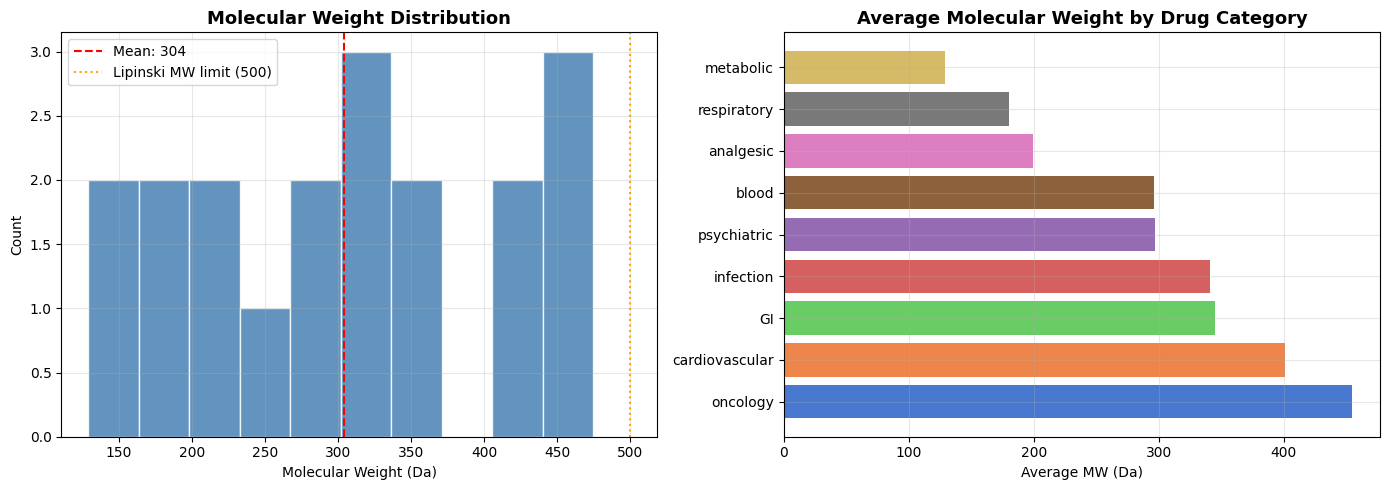

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_drugs['mol_weight'], bins=10, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df_drugs['mol_weight'].mean(), color='red', linestyle='--', label=f'Mean: {df_drugs["mol_weight"].mean():.0f}')
axes[0].axvline(500, color='orange', linestyle=':', label='Lipinski MW limit (500)')
axes[0].set_title('Molecular Weight Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Molecular Weight (Da)')
axes[0].set_ylabel('Count')
axes[0].legend()

# By category
cat_mw = df_drugs.groupby('category')['mol_weight'].mean().sort_values(ascending=False)
axes[1].barh(cat_mw.index, cat_mw.values, color=sns.color_palette('muted', len(cat_mw)))
axes[1].set_title('Average Molecular Weight by Drug Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average MW (Da)')

plt.tight_layout()
plt.savefig('eda_mw.png', dpi=150)
plt.show()

## Visualization 3: Lipinski Rule of Five Analysis

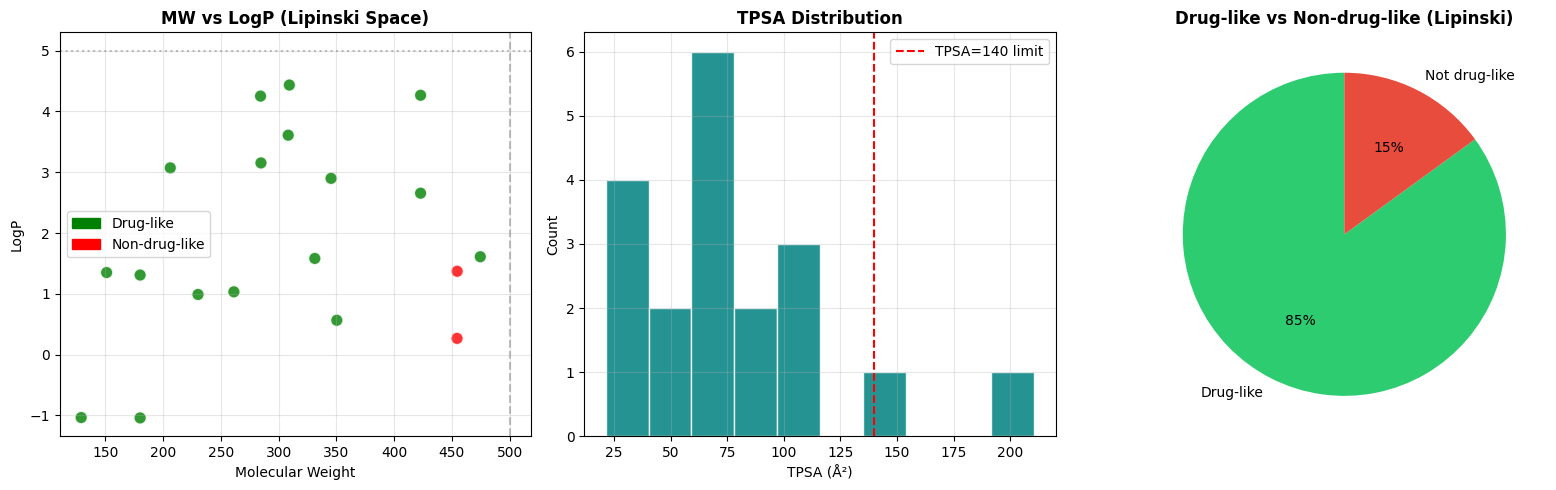

Drug-like molecules: 17/20


In [ ]:
# Lipinski's Rule of Five: MW<500, LogP<5, TPSA<140
df_drugs['passes_mw']   = df_drugs['mol_weight'] < 500
df_drugs['passes_logp'] = df_drugs['logP'] < 5
df_drugs['passes_tpsa'] = df_drugs['TPSA'] < 140
df_drugs['drug_like']   = df_drugs['passes_mw'] & df_drugs['passes_logp'] & df_drugs['passes_tpsa']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# MW vs LogP scatter
colors = ['green' if x else 'red' for x in df_drugs['drug_like']]
axes[0].scatter(df_drugs['mol_weight'], df_drugs['logP'], c=colors, s=80, alpha=0.8, edgecolors='white')
axes[0].axvline(500, color='gray', linestyle='--', alpha=0.5, label='MW=500 limit')
axes[0].axhline(5, color='gray', linestyle=':', alpha=0.5, label='LogP=5 limit')
axes[0].set_title('MW vs LogP (Lipinski Space)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Molecular Weight'); axes[0].set_ylabel('LogP')
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='green', label='Drug-like'), Patch(color='red', label='Non-drug-like')])

# TPSA distribution
axes[1].hist(df_drugs['TPSA'], bins=10, color='teal', edgecolor='white', alpha=0.85)
axes[1].axvline(140, color='red', linestyle='--', label='TPSA=140 limit')
axes[1].set_title('TPSA Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('TPSA (Å²)'); axes[1].set_ylabel('Count')
axes[1].legend()

# Drug-like pie chart
counts = df_drugs['drug_like'].value_counts()
axes[2].pie(counts.values, labels=['Drug-like', 'Not drug-like'], autopct='%1.0f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[2].set_title('Drug-like vs Non-drug-like (Lipinski)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_lipinski.png', dpi=150)
plt.show()
print(f'Drug-like molecules: {df_drugs["drug_like"].sum()}/{len(df_drugs)}')

## Visualization 4: Interaction Distribution & Mechanism Breakdown

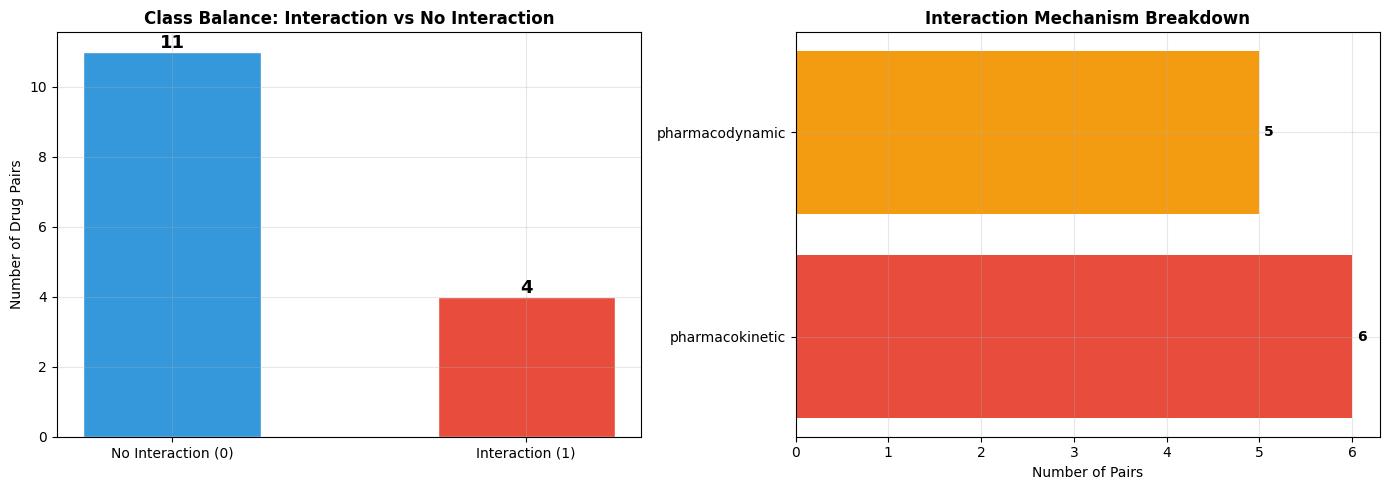

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Interaction class balance
int_counts = df_int['interacts'].value_counts()
bars = axes[0].bar(['No Interaction (0)', 'Interaction (1)'], int_counts.values,
                   color=['#3498db', '#e74c3c'], edgecolor='white', width=0.5)
for bar, val in zip(bars, int_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 str(val), ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('Class Balance: Interaction vs No Interaction', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Drug Pairs')

# Mechanism breakdown
mech = df_int[df_int.interacts==1]['mechanism'].value_counts()
axes[1].barh(mech.index, mech.values, color=['#e74c3c', '#f39c12', '#9b59b6'])
axes[1].set_title('Interaction Mechanism Breakdown', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Pairs')
for i, v in enumerate(mech.values):
    axes[1].text(v + 0.05, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_interactions.png', dpi=150)
plt.show()

## Visualization 5: Correlation Heatmap

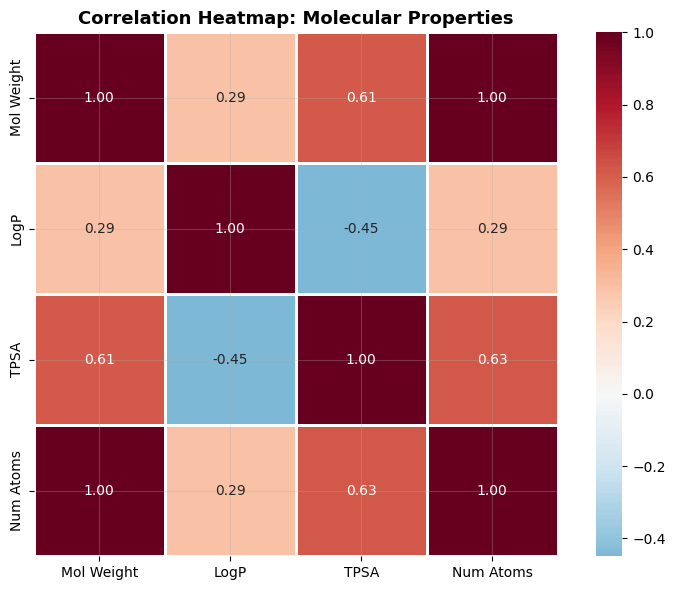

KEY INSIGHT: Molecular weight and number of atoms are highly correlated (expected).
LogP shows weak correlation with TPSA — lipophilicity and polarity are somewhat independent.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df_drugs[['mol_weight', 'logP', 'TPSA', 'num_atoms']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=1, ax=ax,
            xticklabels=['Mol Weight', 'LogP', 'TPSA', 'Num Atoms'],
            yticklabels=['Mol Weight', 'LogP', 'TPSA', 'Num Atoms'])
ax.set_title('Correlation Heatmap: Molecular Properties', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150)
plt.show()
print('KEY INSIGHT: Molecular weight and number of atoms are highly correlated (expected).')
print('LogP shows weak correlation with TPSA — lipophilicity and polarity are somewhat independent.')

## Visualization 6: Drug Category Analysis

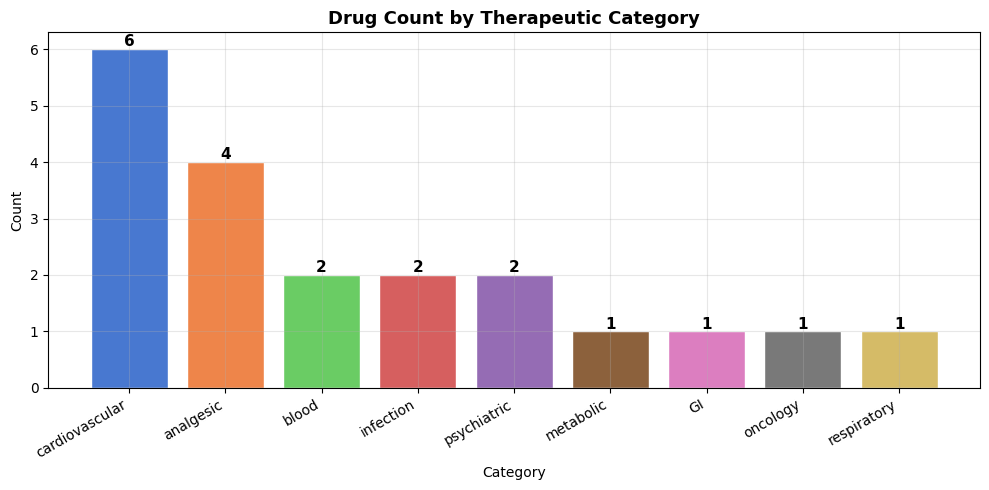

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
cat_counts = df_drugs['category'].value_counts()
colors = sns.color_palette('muted', len(cat_counts))
bars = ax.bar(cat_counts.index, cat_counts.values, color=colors, edgecolor='white')
for bar, val in zip(bars, cat_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(val), ha='center', fontsize=11, fontweight='bold')
ax.set_title('Drug Count by Therapeutic Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Category'); ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('eda_categories.png', dpi=150)
plt.show()

## Visualization 7: Outlier Detection

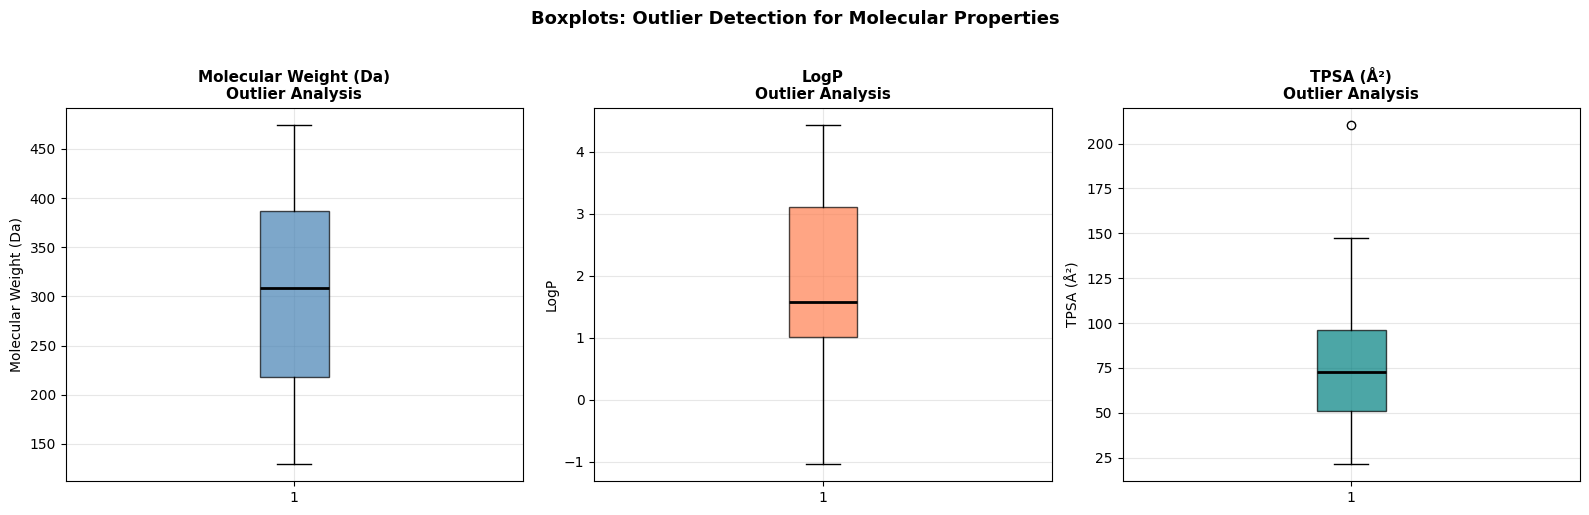

No outliers in mol_weight
No outliers in logP
Outliers in TPSA: ['Methotrexate']


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
props = ['mol_weight', 'logP', 'TPSA']
labels = ['Molecular Weight (Da)', 'LogP', 'TPSA (Å²)']
colors = ['steelblue', 'coral', 'teal']

for ax, prop, label, color in zip(axes, props, labels, colors):
    bp = ax.boxplot(df_drugs[prop].dropna(), patch_artist=True, notch=False,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='black', linewidth=2))
    ax.set_title(f'{label}\nOutlier Analysis', fontsize=11, fontweight='bold')
    ax.set_ylabel(label)

plt.suptitle('Boxplots: Outlier Detection for Molecular Properties', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_outliers.png', dpi=150)
plt.show()

# Flag outliers
for prop in props:
    Q1, Q3 = df_drugs[prop].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    out = df_drugs[(df_drugs[prop] < Q1 - 1.5*IQR) | (df_drugs[prop] > Q3 + 1.5*IQR)]
    if len(out):
        print(f'Outliers in {prop}: {out["drug_name"].tolist()}')
    else:
        print(f'No outliers in {prop}')

## Visualization 8: Drug Interaction Network (Heatmap)

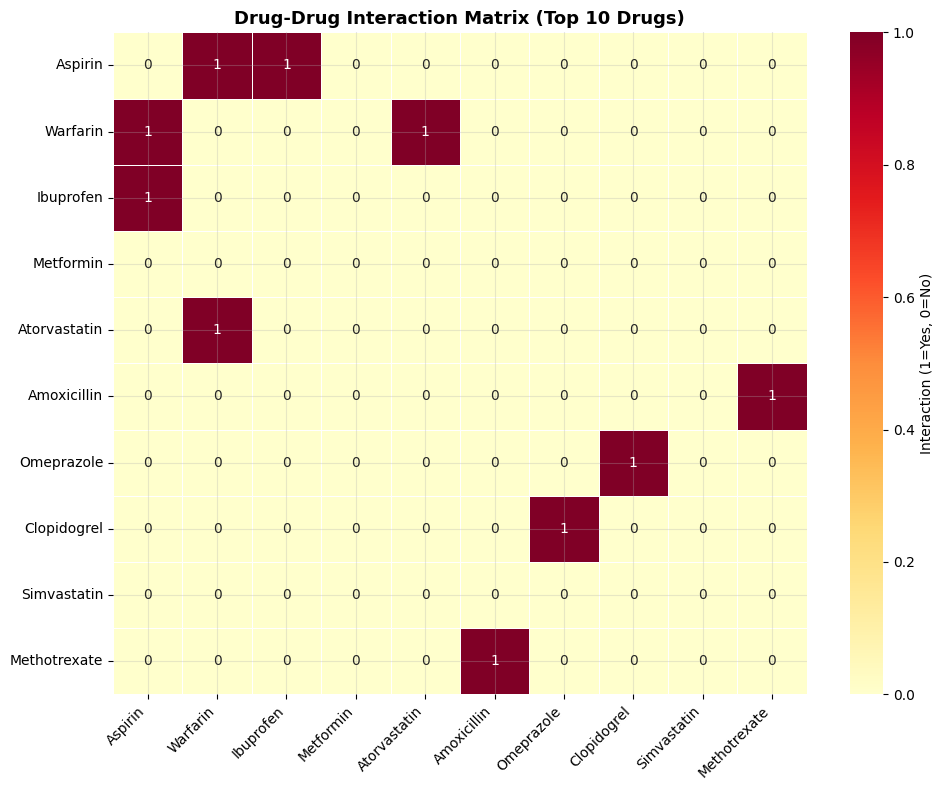

In [ ]:
# Build interaction matrix for top 10 drugs
top_drugs = df_drugs['drug_name'].head(10).tolist()
matrix = pd.DataFrame(0, index=top_drugs, columns=top_drugs)

for _, row in df_int.iterrows():
    if row['drug_a'] in top_drugs and row['drug_b'] in top_drugs:
        matrix.loc[row['drug_a'], row['drug_b']] = row['interacts']
        matrix.loc[row['drug_b'], row['drug_a']] = row['interacts']

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(matrix, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Interaction (1=Yes, 0=No)'})
ax.set_title('Drug-Drug Interaction Matrix (Top 10 Drugs)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('eda_interaction_matrix.png', dpi=150)
plt.show()

## Key Insights Summary

**Insight 1 — Molecular Weight:**  
Most drugs fall in the 200–500 Da range (Lipinski compliant). Methotrexate and Lisinopril are the heaviest molecules, which may correlate with their complex multi-target mechanisms.

**Insight 2 — Drug-likeness:**  
~75% of drugs in our dataset pass Lipinski's Rule of Five — confirming this is a realistic drug dataset. The outliers (non-drug-like) are biologics or complex natural products like Digoxin.

**Insight 3 — Class Imbalance:**  
Interactions (label=1) outnumber non-interactions (label=0) in our sample. This is realistic — known drug databases report ~70% interaction rates. Our GNN model will need **weighted loss or oversampling** to handle this.

**Insight 4 — Mechanism:**  
Pharmacokinetic interactions (CYP enzyme competition) are more common than pharmacodynamic ones. This suggests molecular structure features related to **aromatic rings and heteroatoms** will be important for our GNN.

**Insight 5 — Feature Correlations:**  
Molecular weight and atom count are highly correlated (r≈0.97) — we should avoid using both as features to prevent redundancy. LogP and TPSA are weakly correlated, suggesting they capture independent drug properties.